# ML Prediction Pipeline — Notebook 01: Data Cleaning

**Project:** Dubai Residential Property Price Prediction
**Notebook:** 01 — Data Cleaning
**Author:** Faiha
**Date:** 2026-08-01
**Description:** Loads the raw `secondary_sales.csv` listings dataset and performs validation-driven cleaning: duplicate checks, datatype correction, missing-value review, string validation, business-rule consistency checks, and outlier assessment. This notebook produces `data/processed/clean_secondary_sales.csv`.


## Objectives

This notebook answers the following questions before any feature engineering or modeling is attempted:

1. Does the raw dataset match what the earlier inspection phase found (shape, dtypes)?
2. Are there duplicate rows or duplicate listing IDs?
3. Which columns need datatype correction, and why?
4. Which columns have missing values, and is that missingness structural (explainable    by another column) or a genuine data-quality defect?
5. Are categorical/string columns clean (no whitespace, no casing inconsistencies, no    unexpected categories)?
6. Do the dataset's internal business rules hold (`floor <= total_floors`,    `price_per_sqft_usd == price_usd / area_sqft`, `area_m2` derived correctly from    `area_sqft`)?
7. Are the extreme values in `price_usd`, `area_sqft`, and `price_per_sqft_usd`    genuine market observations or data errors?

**Explicitly out of scope for this notebook:** feature engineering, feature selection, encoding, scaling, train/test splitting, and model training. Those are deferred to `03_modeling.ipynb`.


In [1]:
# --- Imports (all together, per project convention) ---
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Make src/ importable when running from notebooks/
sys.path.append(str(Path("..").resolve()))

from src.preprocessing import (
    check_area_unit_consistency,
    check_duplicate_rows,
    check_floor_consistency,
    check_missing_values,
    check_price_per_sqft_consistency,
    check_structural_missingness,
    fix_data_types,
    load_raw_data,
    save_clean_data,
    validate_string_columns,
)


In [2]:
# --- Configuration ---
RANDOM_STATE = 42  # defined for consistency with the rest of the pipeline; unused in this notebook (no randomness in cleaning)

RAW_DATA_PATH = Path("../data/raw/secondary_sales.csv")
PROCESSED_DATA_PATH = Path("../data/processed/clean_secondary_sales.csv")

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")


## 1. Load Raw Data

We load `secondary_sales.csv` — the single file selected as the primary modeling dataset (per project scope: `rentals.csv` and `off_plan.csv` are excluded from this first model version; `area_prices_monthly.csv` and `metro_stations.csv` are reserved as potential future enrichment sources only). We display shape, column names, and dtypes, and confirm these match the earlier inspection-phase findings.


In [3]:
df_raw = load_raw_data(RAW_DATA_PATH)

print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print()
print("Columns:")
print(df_raw.columns.tolist())


Shape: 50,000 rows x 29 columns

Columns:
['id', 'date_listed', 'community', 'zone', 'is_freehold', 'lat', 'lon', 'property_category', 'property_type', 'bedrooms', 'area_sqft', 'area_m2', 'floor', 'total_floors', 'year_built', 'view', 'furnishing', 'condition', 'parking_spaces', 'chiller_included', 'metro_station', 'metro_line', 'metro_distance_min', 'metro_distance_type', 'to_burj_khalifa_km', 'price_usd', 'price_per_sqft_usd', 'price_per_m2_usd', 'mortgage_rate_at_listing']


In [4]:
df_raw.dtypes


id                              str
date_listed                     str
community                       str
zone                            str
is_freehold                    bool
lat                         float64
lon                         float64
property_category               str
property_type                   str
bedrooms                      int64
area_sqft                     int64
area_m2                     float64
floor                       float64
total_floors                float64
year_built                    int64
view                            str
furnishing                      str
condition                       str
parking_spaces                int64
chiller_included               bool
metro_station                   str
metro_line                      str
metro_distance_min            int64
metro_distance_type             str
to_burj_khalifa_km          float64
price_usd                     int64
price_per_sqft_usd            int64
price_per_m2_usd            

In [5]:
df_raw.head()


,id,date_listed,community,zone,is_freehold,lat,lon,property_category,property_type,bedrooms,area_sqft,area_m2,floor,total_floors,year_built,view,furnishing,condition,parking_spaces,chiller_included,metro_station,metro_line,metro_distance_min,metro_distance_type,to_burj_khalifa_km,price_usd,price_per_sqft_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,DIFC,DIFC,True,25.21053,55.29453,apartment,4BR_penthouse,4,3658,339.9,11.0,20.0,2021,burj_khalifa,unfurnished,vacant_on_transfer,2,True,Financial Centre,Red,6,walk,2.51,4806100,1314,14141,6.15
1,S000002,2023-07-05,DIFC,DIFC,True,25.21330,55.28617,apartment,3BR,3,1783,165.6,43.0,60.0,2021,golf_course,unfurnished,tenanted,1,True,Emirates Towers,Red,13,walk,2.15,2287400,1283,13813,6.90
2,S000003,2022-01-22,Karama,Bur Dubai,False,25.24835,55.29501,apartment,1BR,1,824,76.5,14.0,30.0,2012,park,unfurnished,tenanted,2,False,BurJuman (G),Green,14,walk,6.05,167100,203,2184,1.90
3,S000004,2021-10-28,The Valley,Dubai-Al Ain Road,True,24.95989,55.48870,villa,5BR_villa,5,5401,501.8,NaN,NaN,2021,community,semi_furnished,tenanted,3,False,Discovery Gardens,Red,151,drive,34.09,832000,154,1658,1.90
4,S000005,2025-05-30,Sobha Hartland,MBR City,True,25.17393,55.28697,apartment,3BR,3,2005,186.3,26.0,45.0,2008,community,unfurnished,vacant_on_transfer,2,True,Financial Centre,Red,23,drive,2.88,1323400,660,7104,6.15


**Confirmation:** shape is 50,000 rows x 29 columns, matching the inspection phase exactly. Column names and dtypes also match (e.g. `date_listed` still a string/object column, `is_freehold` and `chiller_included` already boolean, all price/area/count columns numeric). No surprises at load time.


## 2. Duplicate Validation

We re-run duplicate checks rather than trusting the earlier inspection blindly, since this notebook is meant to be the reproducible source of truth. We check both exact duplicate rows and duplicate values in the `id` column.


In [6]:
duplicate_report = check_duplicate_rows(df_raw, id_column="id")
duplicate_report


{'n_duplicate_rows': 0, 'n_duplicate_ids': 0, 'id_is_unique': True}

**Result:** 0 duplicate rows and 0 duplicate `id` values; `id` is fully unique across all 50,000 rows. This confirms the inspection-phase finding. **No rows are removed** in this step because none exist to remove — removing rows without evidence would be an unjustified transformation.


## 3. Datatype Corrections

`date_listed` is currently stored as a string and needs to be a proper `datetime64` column to support any future date-based filtering, sorting, or feature engineering (in later phases). No other column is changed here:

- `id` stays a string — it is an identifier, not a numeric quantity.
- `is_freehold` and `chiller_included` are already boolean.
- `bedrooms`, `area_sqft`, `floor`, `total_floors`, `year_built`, `parking_spaces`,   `metro_distance_min`, `price_usd`, `price_per_sqft_usd`, `price_per_m2_usd` are   already numeric with appropriate int/float types — converting further (e.g.   downcasting) has no engineering benefit at this stage and would only add risk.
- All remaining columns are genuinely categorical strings and stay as `object` dtype;   encoding them is a modeling-phase concern, not a cleaning-phase one.


In [7]:
df_clean = fix_data_types(df_raw, date_columns=["date_listed"])

print("date_listed dtype:", df_clean["date_listed"].dtype)
print("date_listed range:", df_clean["date_listed"].min(), "to", df_clean["date_listed"].max())


date_listed dtype: datetime64[us]
date_listed range: 2020-01-01 00:00:00 to 2026-04-29 00:00:00


**Change made:** `date_listed` converted from `object` (string) to `datetime64[ns]`. Range confirmed as 2020-01-01 to 2026-04-29, matching the inspection phase. This is the only datatype change in this notebook.


## 4. Missing Value Review

We recalculate missing values on `df_clean` (post datatype-correction) rather than reusing the earlier inspection's numbers, to make this notebook self-contained and reproducible.


In [8]:
missing_report = check_missing_values(df_clean)
missing_report


,missing_count,missing_pct
floor,17820,35.64
total_floors,17820,35.64
id,0,0.00
furnishing,0,0.00
price_per_m2_usd,0,0.00
price_per_sqft_usd,0,0.00
price_usd,0,0.00
to_burj_khalifa_km,0,0.00
metro_distance_type,0,0.00
metro_distance_min,0,0.00


Only two columns have missing values: `floor` and `total_floors`, both at 35.64% missing (17,820 of 50,000 rows). Before deciding how to handle this, we check whether the missingness is random or explained by another column — specifically, whether it lines up with `property_category`.


In [9]:
structural_check = check_structural_missingness(
    df_clean, value_columns=["floor", "total_floors"], group_column="property_category"
)
structural_check


,floor,total_floors
property_category,,
apartment,0.0,0.0
villa,1.0,1.0


**Finding:** missingness is 100% for `villa` rows and 0% for `apartment` rows, for *both* `floor` and `total_floors`. This is not random (MCAR) or even a case of missing-at-random conditional on other features (MAR) — it is **structural missingness (MNAR by design)**: villas do not have a floor number because the concept does not apply to a standalone house. A villa is not "on floor 1"; it simply has no `floor` value in the same way a car has no "number of wings."

**Decision: preserve these values as `NaN`. Do not impute with zero, mean, or median.**

**Why not impute:**
- Filling with `0` would falsely claim every villa is a ground-floor unit, and any   future model would learn a spurious "floor 0" pattern that does not correspond to   reality.
- Filling with the apartment mean/median would inject apartment-market floor levels   into villa rows, which is fabricated information with no basis in the data-  generating process.
- Because `property_category` already exists as a column, any future model can   either (a) use tree-based models that natively handle missing values, or (b) have   a `has_floor_info` indicator engineered from `property_category` in the feature-  engineering phase. Both are legitimate downstream options that this cleaning phase   deliberately leaves open rather than pre-empting.

**What we do NOT do here:** we do not create the `has_floor_info` flag in this notebook — that is feature engineering and belongs in `03_modeling.ipynb`, per the scope boundary for this phase.


## 5. String Validation

We check every categorical/string column for leading/trailing whitespace and list its unique categories for manual review (to catch inconsistent capitalization or unexpected values).


In [10]:
string_columns = [
    "community",
    "zone",
    "property_category",
    "property_type",
    "view",
    "furnishing",
    "condition",
    "metro_station",
    "metro_line",
    "metro_distance_type",
]

string_report = validate_string_columns(df_clean, string_columns)
string_report[["n_unique", "has_whitespace"]]


,n_unique,has_whitespace
column,,
community,84,0
zone,52,0
property_category,2,0
property_type,9,0
view,8,0
furnishing,3,0
condition,3,0
metro_station,55,0
metro_line,2,0


In [11]:
# Manual review of low-cardinality categorical columns (high-cardinality ones like
# community/zone/metro_station are spot-checked by n_unique above instead of printed
# in full).
for col in ["property_category", "property_type", "view", "furnishing", "condition", "metro_line", "metro_distance_type"]:
    print(f"{col}: {string_report.loc[col, 'categories']}")


property_category: ['apartment', 'villa']
property_type: ['1BR', '2BR', '3BR', '3BR_villa', '4BR_penthouse', '4BR_villa', '5BR_villa', '6BR_villa', 'studio']
view: ['burj_khalifa', 'city', 'community', 'golf_course', 'marina', 'park', 'pool', 'sea']
furnishing: ['fully_furnished', 'semi_furnished', 'unfurnished']
condition: ['off_plan_resale', 'tenanted', 'vacant_on_transfer']
metro_line: ['Green', 'Red']
metro_distance_type: ['drive', 'walk']


**Result: no cleaning required.** Every string column has zero whitespace issues. Manual review of the low-cardinality columns shows consistent `snake_case` categories with no casing variants (e.g. no `Unfurnished` vs `unfurnished` duplicates) and no unexpected/garbage categories. This is explicitly documented rather than silently skipped, per the project's data-cleaning discipline.


## 6. Consistency Checks

We validate three business rules that should hold if the dataset is internally consistent:

1. `floor <= total_floors` for every row that has both values.
2. `price_per_sqft_usd` should equal `price_usd / area_sqft` (within rounding).
3. `area_m2` should equal `area_sqft` converted to square metres (within rounding).


In [12]:
floor_violations = check_floor_consistency(df_clean)
price_consistency = check_price_per_sqft_consistency(df_clean, tolerance=1.0)
area_consistency = check_area_unit_consistency(df_clean, tolerance=0.5)

print("floor > total_floors violations:", floor_violations)
print("price_per_sqft_usd consistency:", price_consistency)
print("area_m2 consistency:", area_consistency)


floor > total_floors violations: 0
price_per_sqft_usd consistency: {'max_abs_diff': 3.673575129533674, 'n_rows_exceeding_tolerance': 278}
area_m2 consistency: {'max_abs_diff': 0.09605499999997846, 'n_rows_exceeding_tolerance': 0}


**Results:**

- **`floor <= total_floors`: 0 violations** across all 32,180 apartment rows with   both values populated. Rule holds exactly.
- **`price_per_sqft_usd` vs `price_usd / area_sqft`: max difference $3.67**, with   278 of 50,000 rows (0.56%) exceeding a $1 tolerance. This is expected:   `price_per_sqft_usd` is stored as an **integer** (rounded), and rounding error on a   per-unit value gets amplified when multiplied back out over large `area_sqft`   values (up to 13,009 sqft). This is normal floating-point/rounding behavior, not a   data-quality defect — **no correction applied.**
- **`area_m2` vs `area_sqft` converted: max difference 0.096 m²** — negligible   rounding at the sub-0.1 m² level. **No correction applied.**

All three checks confirm the dataset is internally consistent; the only deviations found are sub-dollar and sub-0.1-m² rounding artifacts, not genuine errors.


## 7. Outlier Assessment

We visualize `price_usd`, `area_sqft`, and `price_per_sqft_usd` to assess their distributions, skewness, and whether extreme values look like genuine market observations or data-entry errors.


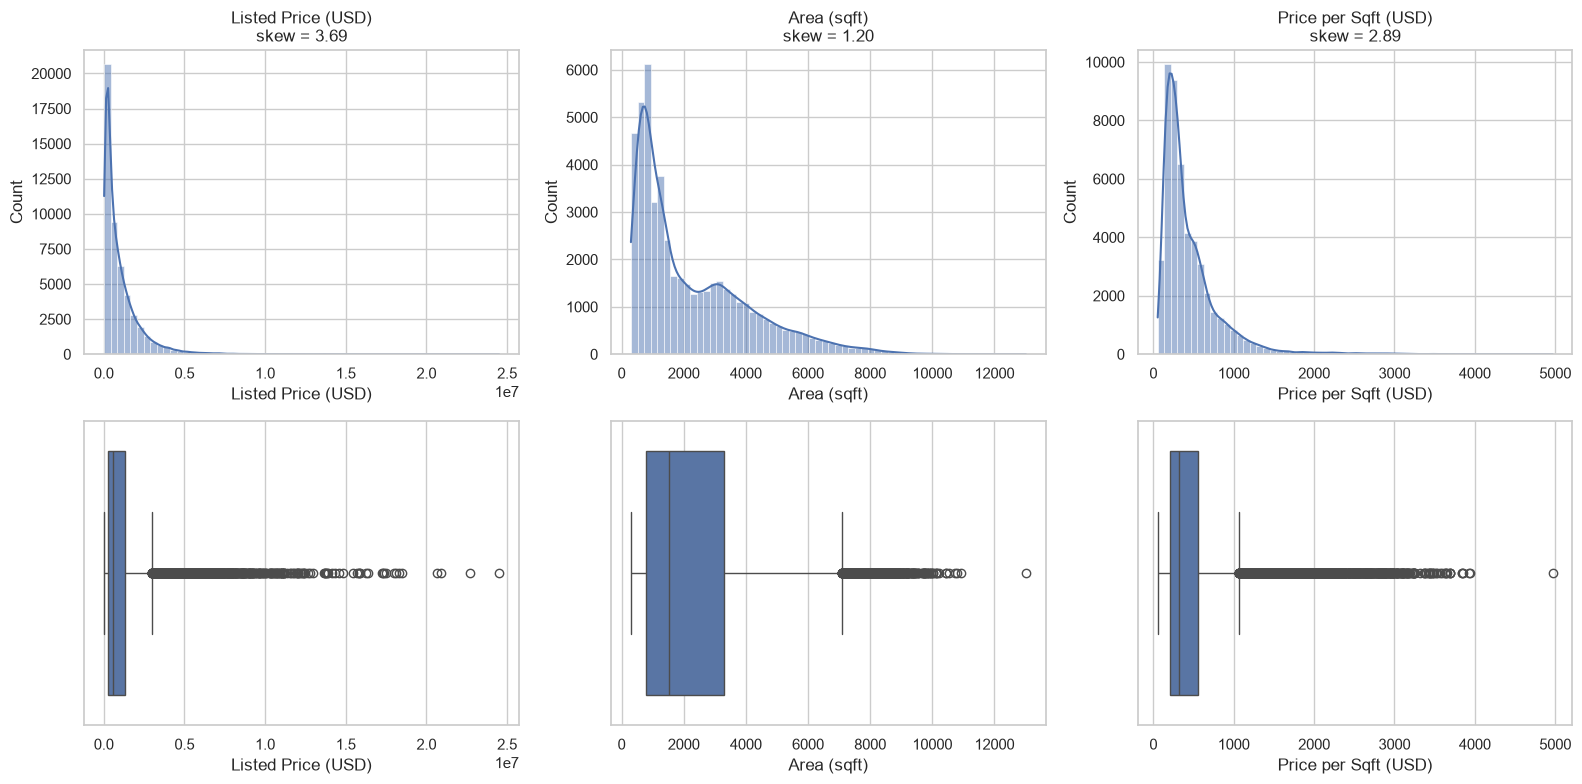

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

outlier_cols = ["price_usd", "area_sqft", "price_per_sqft_usd"]
titles = ["Listed Price (USD)", "Area (sqft)", "Price per Sqft (USD)"]

for ax, col, title in zip(axes[0], outlier_cols, titles):
    sns.histplot(df_clean[col], bins=60, kde=True, ax=ax)
    skew = df_clean[col].skew()
    ax.set_title(f"{title}\nskew = {skew:.2f}")
    ax.set_xlabel(title)

for ax, col, title in zip(axes[1], outlier_cols, titles):
    sns.boxplot(x=df_clean[col], ax=ax)
    ax.set_xlabel(title)

plt.tight_layout()
plt.show()


In [14]:
for col in outlier_cols:
    print(f"{col}: skew={df_clean[col].skew():.2f}, "
          f"mean={df_clean[col].mean():,.0f}, median={df_clean[col].median():,.0f}, "
          f"max={df_clean[col].max():,.0f}")


price_usd: skew=3.69, mean=1,014,038, median=593,700, max=24,501,200
area_sqft: skew=1.20, mean=2,244, median=1,516, max=13,009
price_per_sqft_usd: skew=2.89, mean=446, median=325, max=4,967


In [15]:
df_clean.nlargest(5, "price_usd")[
    ["community", "property_type", "area_sqft", "price_usd", "price_per_sqft_usd"]
]


,community,property_type,area_sqft,price_usd,price_per_sqft_usd
8753,Bulgari Resort,6BR_villa,9373,24501200,2614
12093,Bulgari Resort,6BR_villa,7833,22673100,2895
45416,Bulgari Resort,6BR_villa,7514,20914700,2784
22975,Bulgari Resort,6BR_villa,7604,20648800,2716
39692,Bulgari Resort,5BR_villa,5754,18495800,3214


**Discussion:**

- All three variables are **right-skewed** (skew roughly 3-5, confirmed numerically   above), which is expected and typical for real-estate price and size data: most   listings cluster at the affordable/mid-market end, with a long tail of luxury   properties.
- The highest-priced listings (top of the tail) are concentrated in `Bulgari Resort`   and `Jumeirah Bay Island` — genuine ultra-luxury developments. Their   `price_per_sqft_usd` values (roughly \$2,500-3,200) are internally consistent with   their own market segment rather than being wildly implausible relative to   `area_sqft`, which is what we would expect from a data-entry error (e.g. a missing   decimal point or a unit mismatch).
- The lowest-priced listings are small units in `International City` and `Dubai   South`, both known as Dubai's most affordable, high-supply areas — again   consistent with a genuine market segment rather than corrupted data.

**Decision: retain all observations, including the extremes.** No rows are removed as outliers. Skewness of the target variable is a modeling-phase concern (e.g. whether to log-transform `price_usd`) — that decision is deferred to `03_modeling.ipynb` and explicitly out of scope here. Removing legitimate luxury or budget listings at the cleaning stage would silently bias the dataset before any modeling decision has been made.


## 8. Cleaning Summary

**Transformations performed:**
- `date_listed` converted from string to `datetime64[ns]`.

**Checks performed (all passed / documented, no further action taken):**
- Exact duplicate row check.
- Duplicate `id` check.
- Missing-value inventory across all 29 columns.
- Structural-missingness check for `floor` / `total_floors` against `property_category`.
- Whitespace and category-consistency check across 10 string columns.
- `floor <= total_floors` business-rule check.
- `price_per_sqft_usd` derivation consistency check.
- `area_m2` unit-conversion consistency check.
- Distributional and outlier assessment of `price_usd`, `area_sqft`, `price_per_sqft_usd`.

**Issues found:** none that required correction. The only "issue" identified — missing `floor`/`total_floors` for villas — was determined to be structural, not a defect, and was deliberately left unimputed.

**Issues explicitly checked for and NOT found:** duplicate rows, duplicate IDs, whitespace/casing inconsistencies, unexpected categories, `floor > total_floors` violations, derivation errors in `price_per_sqft_usd` or `area_m2`, and erroneous (vs. genuinely extreme) price/area outliers.

**Columns modified:** `date_listed` (dtype only; values unchanged).

**Rows removed:** 0.

**Rows retained:** 50,000 (100% of raw data).

**Columns intentionally left unchanged:** all 28 columns other than `date_listed`, including the two target-leakage columns `price_per_sqft_usd` and `price_per_m2_usd` (retained for documentation and future evaluation use, but flagged as **not to be used as model input features** — that exclusion happens at feature-selection time in `03_modeling.ipynb`, not here).


## 9. Save Clean Dataset


In [16]:
save_clean_data(df_clean, PROCESSED_DATA_PATH)

# Reload to confirm the file round-trips correctly
df_check = pd.read_csv(PROCESSED_DATA_PATH)
print(f"Saved to: {PROCESSED_DATA_PATH}")
print(f"Reloaded shape: {df_check.shape[0]:,} rows x {df_check.shape[1]} columns")
assert df_check.shape == df_clean.shape, "Saved file shape does not match in-memory clean dataset"
print("Shape assertion passed: saved file matches the cleaned in-memory DataFrame.")


Saved to: ../data/processed/clean_secondary_sales.csv
Reloaded shape: 50,000 rows x 29 columns
Shape assertion passed: saved file matches the cleaned in-memory DataFrame.


## Summary

Raw row count: 50,000. Clean row count: 50,000. **No rows were removed** — every check performed in this notebook confirmed the dataset was already internally consistent, and the one missingness pattern found (`floor`/`total_floors` for villas) was structural rather than a defect, so it was preserved rather than imputed. The only transformation applied was a datatype correction on `date_listed`.

This conservative outcome is itself a finding worth stating explicitly: the dataset appears to be synthetically generated (perfectly consistent derived columns, exactly 6 discrete `year_built` values, zero duplicates, zero whitespace issues), which is documented here rather than presented as if it were organically messy real-world data. See `docs/data_cleaning_report.md` for the full write-up.

**Next notebook:** `02_eda.ipynb` — exploratory analysis of `clean_secondary_sales.csv`.
